# Directed Acyclic Graphs

# When we see an association in data, how do we decide whether and how to adjust for other variables?

## Association only?  Not enough.

## Confounder that affects X and Y?  Control for it.  Consider polynomial and interaction terms if need be.

## Collider?  Don't control for it, it would make things worse.

## Omitted variable?

# Outline

1. **The value of visualization**

- How can we show the causal relationships between our data features?

- Directed Acyclic Graphs

2. **Association is not enough: when controlling helps**

- What is it called when a single features causes both the treatment and the outcome?

- A confounder

3. **What if you leave out or fail to measure some variables?**

- What is the difference between noise and omitted variables?

- They are often the same: omitted variables can cause noise.

- Omitted variables that are confounders will cause problems, however.
    
4. **DAGs do not show a functional form**

- How are quadratic and interaction terms shown on a DAG?

- They often are not shown differently from any other effect.

5. **Colliders: when controlling makes things worse**

- Should you control for colliders, confounders, or both?

- You can control for confounders but not for colliders.

# DAGs, coffee, smoking, and lung cancer


## Suppose that a public health analyst sees that coffee drinkers have higher lung cancer rates. Should the department issue a warning about coffee?

## Does coffee cause lung cancer?

## Nodes

## Directed edges

## Acyclic

## Correlation vs. cause

## Source

## Sink

## Why DAGs are important

### Don't control for colliders

### Know if you've omitted any variables

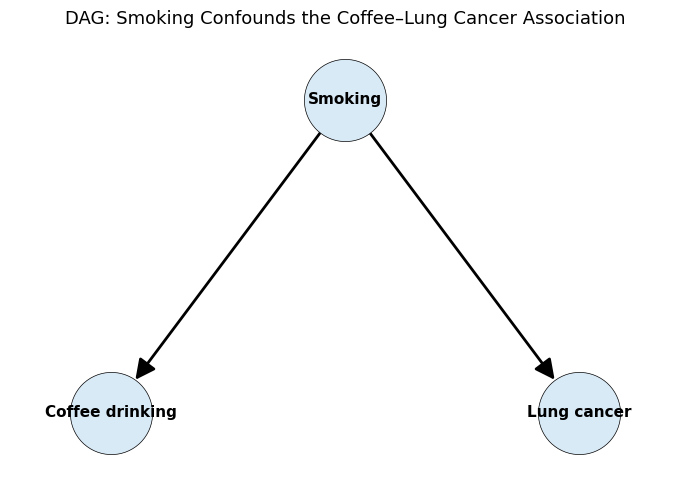

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

G.add_nodes_from([
    "Smoking",
    "Coffee drinking",
    "Lung cancer",
])

G.add_edges_from([
    ("Smoking", "Coffee drinking"),
    ("Smoking", "Lung cancer")
])

pos = {
    "Smoking": (0, 1),
    "Coffee drinking": (-1, 0),
    "Lung cancer": (1, 0),
}

plt.figure(figsize=(7, 5))

ax = plt.gca()
ax.margins(0.15)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500,
    node_color="#D9EAF7",
    edgecolors="black",
    linewidths=0.5
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=30,
    width=2,
    node_size=3500,
    min_source_margin=15,
    min_target_margin=15
)


nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)

plt.title("DAG: Smoking Confounds the Coffee–Lung Cancer Association", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

# Noise terms, omitted variables, and electricity demand

## You work for an electric utility. Tomorrow may be extremely hot. Your job is to predict demand so the grid has enough supply.  You want to know: by how much might your model be wrong?

## In many statistical models, we write an outcome as a systematic part plus a noise term. 

## A noise term is not just "randomness" - it represents some omitted or unmeasured variables.

## Omitting variables affects the noise and affects residuals.

## Noise term represents all influences on the outcome that are not represented on the DAG.

## Therefore, the size of the noise term is not fixed.

## Why residuals are important: the tell us how much we have left out or what remains unexplained.

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(42)

n_days = 365 * 3
dates = pd.date_range(start="2021-01-01", periods=n_days, freq="D")

df = pd.DataFrame({"date": dates})

df["day_of_year"] = df["date"].dt.dayofyear
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

df["weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["holiday"] = 0
for year in df["date"].dt.year.unique():
    holiday_dates = pd.to_datetime([
        f"{year}-01-01",
        f"{year}-07-04",
        f"{year}-11-25",
        f"{year}-12-25"
    ])
    df.loc[df["date"].isin(holiday_dates), "holiday"] = 1

seasonal_temperature = 60 + 20 * np.sin(2 * np.pi * (df["day_of_year"] - 172) / 365)
temperature_noise = np.random.normal(0, 6, size=n_days)
df["temperature"] = seasonal_temperature + temperature_noise

df["cooling_degree"] = np.maximum(df["temperature"] - 65, 0)
df["heating_degree"] = np.maximum(55 - df["temperature"], 0)

df["annual_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["annual_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

epsilon = np.random.normal(0, 8, size=n_days)

df["demand"] = (
    300
    + 4.0 * df["cooling_degree"]
    + 3.0 * df["heating_degree"]
    - 20.0 * df["weekend"]
    - 35.0 * df["holiday"]
    + 12.0 * df["annual_sin"]
    - 8.0 * df["annual_cos"]
    + epsilon
)

feature_columns = [
    "cooling_degree",
    "heating_degree",
    "weekend",
    "holiday",
    "annual_sin",
    "annual_cos"
]

X_full = sm.add_constant(df[feature_columns])
y = df["demand"]

model_full = sm.OLS(y, X_full).fit()

print("\nFULL MODEL")
print("Features used:", feature_columns)
print("Residual standard error:", np.sqrt(model_full.mse_resid))
print("BSEs:")
print(model_full.bse)

features_to_drop = [
    "cooling_degree",
    "heating_degree",
    "holiday"
]

reduced_feature_columns = [
    col for col in feature_columns if col not in features_to_drop
]

X_reduced = sm.add_constant(df[reduced_feature_columns])

model_reduced = sm.OLS(y, X_reduced).fit()

print("\nPrediction: If we remove temperature and holiday variables from the model, what should happen to the residual standard error?")
print("A. It should decrease.")
print("B. It should stay about the same.")
print("C. It should increase.")

print("\nREDUCED MODEL")
print("Features used:", reduced_feature_columns)
print("Features dropped:", features_to_drop)
print("Residual standard error:", np.sqrt(model_reduced.mse_resid))
print("BSEs:")
print(model_reduced.bse)

print("\nIf your model ignores temperature, heat waves look like random shocks. But they are not random from the perspective of a better model.")

comparison = pd.DataFrame({
    "full_model_bse": model_full.bse,
    "reduced_model_bse": model_reduced.bse
})

print("\nBSE COMPARISON")
print(comparison)

print("\nMODEL FIT COMPARISON")
print(pd.DataFrame({
    "model": ["full", "reduced"],
    "num_features": [len(feature_columns), len(reduced_feature_columns)],
    "residual_standard_error": [
        np.sqrt(model_full.mse_resid),
        np.sqrt(model_reduced.mse_resid)
    ],
    "r_squared": [
        model_full.rsquared,
        model_reduced.rsquared
    ],
    "adj_r_squared": [
        model_full.rsquared_adj,
        model_reduced.rsquared_adj
    ]
}))


FULL MODEL
Features used: ['cooling_degree', 'heating_degree', 'weekend', 'holiday', 'annual_sin', 'annual_cos']
Residual standard error: 8.003203220275891
BSEs:
const             0.420479
cooling_degree    0.056961
heating_degree    0.059188
weekend           0.536000
holiday           2.344507
annual_sin        0.739663
annual_cos        0.364061
dtype: float64

Prediction: If we remove temperature and holiday variables from the model, what should happen to the residual standard error?
A. It should decrease.
B. It should stay about the same.
C. It should increase.

REDUCED MODEL
Features used: ['weekend', 'annual_sin', 'annual_cos']
Features dropped: ['cooling_degree', 'heating_degree', 'holiday']
Residual standard error: 26.830241051035074
BSEs:
const         0.960063
weekend       1.792849
annual_sin    1.146654
annual_cos    1.146660
dtype: float64

If your model ignores temperature, heat waves look like random shocks. But they are not random from the perspective of a better mode

# Draw the DAG:

## Combine the following variables into a DAG: 

## Seasonality (season / month of the year)

## Day of the week

## Temperature

## Holiday

## Electricity demand (Outcome)

# Prediction:

## What shape should the temperature-electricity demand relationship have?

## A) Electricity demand increases with temperature

## B) It decreases with temperature

## C) It is not caused by temperature

## D) It is high for both cold and hot temperatures and lower in between

## E) It is low for both cold and hot temperatures and higher in between

# DAG arrows do not tell us the functional form

## A quadratic term helps here because on mild days, electricity demand may be relatively low. People may not need much heating or air conditioning. But on very cold days, demand rises because buildings need heating, and on hot days they need air conditioning. Electricity demand is U-shaped.

## demand = a + b × temperature, vs.

## demand = a + b₁ × temperature + b₂ × temperature².

## DAG does not, by itself, tell us the shape of the function.

## DAGs are not complete statistical models.

## Takeaway: an arrow in a DAG says, “this variable may matter causally.” It does not say, “this variable matters in a straight line / linearly.”

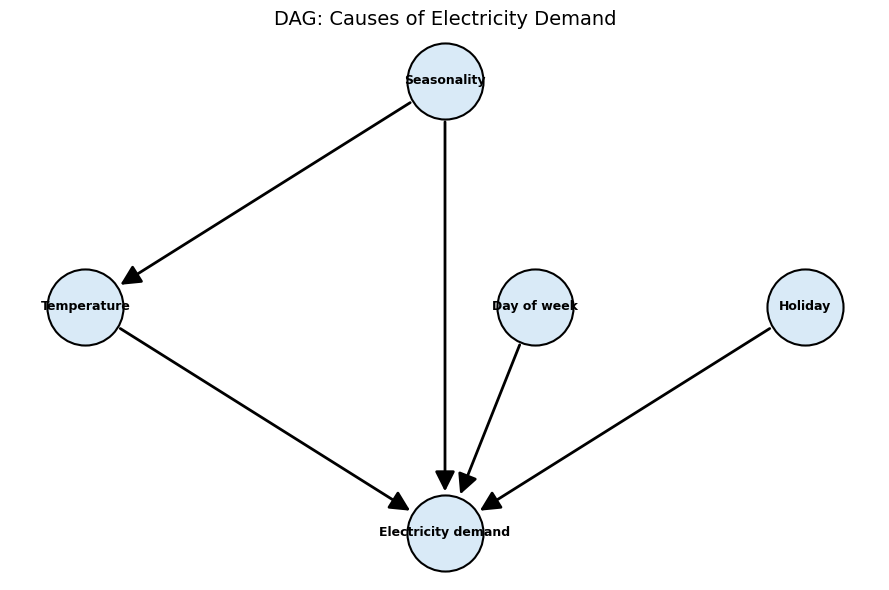

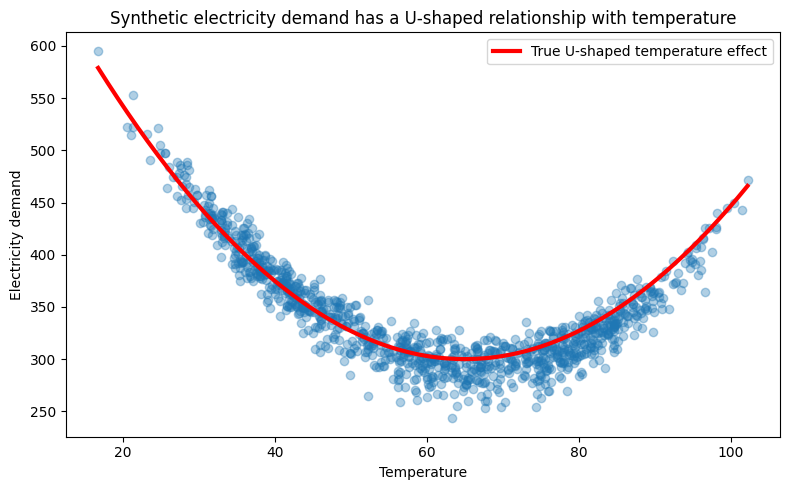


LINEAR TEMPERATURE MODEL
                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     113.3
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           1.76e-96
Time:                        13:43:57   Log-Likelihood:                -5638.7
No. Observations:                1095   AIC:                         1.129e+04
Df Residuals:                    1089   BIC:                         1.132e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         405.1289  

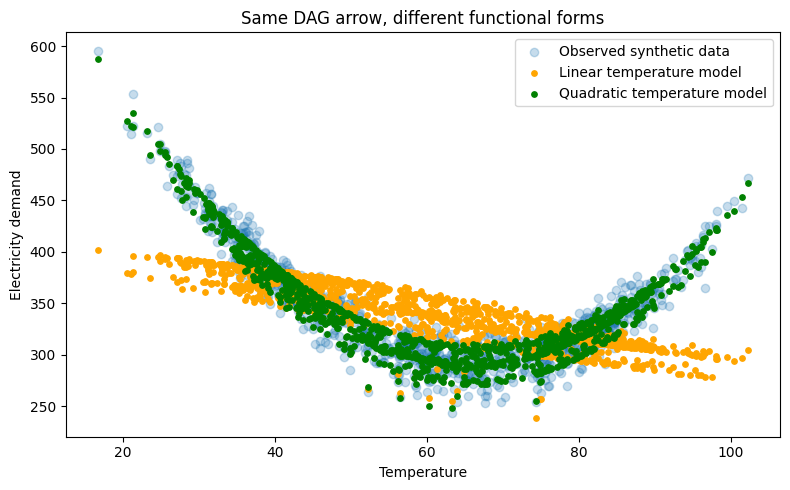

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm

np.random.seed(42)

n_days = 365 * 3
dates = pd.date_range(start="2021-01-01", periods=n_days, freq="D")

df = pd.DataFrame({"date": dates})
df["day_of_year"] = df["date"].dt.dayofyear
df["day_of_week"] = df["date"].dt.dayofweek
df["weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["holiday"] = 0
for year in df["date"].dt.year.unique():
    holiday_dates = pd.to_datetime([
        f"{year}-01-01",
        f"{year}-07-04",
        f"{year}-11-25",
        f"{year}-12-25"
    ])
    df.loc[df["date"].isin(holiday_dates), "holiday"] = 1

seasonal_temperature = 60 + 25 * np.sin(2 * np.pi * (df["day_of_year"] - 172) / 365)
temperature_noise = np.random.normal(0, 7, size=n_days)
df["temperature"] = seasonal_temperature + temperature_noise

df["annual_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["annual_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

comfortable_temperature = 65
df["temperature_centered"] = df["temperature"] - comfortable_temperature
df["temperature_centered_sq"] = df["temperature_centered"] ** 2

epsilon = np.random.normal(0, 10, size=n_days)

df["demand"] = (
    300
    + 0.12 * df["temperature_centered_sq"]
    - 18 * df["weekend"]
    - 30 * df["holiday"]
    + 10 * df["annual_sin"]
    - 6 * df["annual_cos"]
    + epsilon
)

G = nx.DiGraph()

G.add_nodes_from([
    "Temperature",
    "Day of week",
    "Holiday",
    "Seasonality",
    "Electricity demand"
])

G.add_edges_from([
    ("Temperature", "Electricity demand"),
    ("Day of week", "Electricity demand"),
    ("Holiday", "Electricity demand"),
    ("Seasonality", "Temperature"),
    ("Seasonality", "Electricity demand")
])

pos = {
    "Seasonality": (0, 2),
    "Temperature": (-2, 1),
    "Day of week": (0.5, 1),
    "Holiday": (2, 1),
    "Electricity demand": (0, 0)
}

plt.figure(figsize=(9, 6))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3000,
    node_color="#D9EAF7",
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=30,
    width=2,
    node_size = 3500,
    edge_color="black",
    min_source_margin=15,
    min_target_margin=20
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

plt.title("DAG: Causes of Electricity Demand", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["demand"], alpha=0.35)

temp_grid = np.linspace(df["temperature"].min(), df["temperature"].max(), 200)
true_curve = 300 + 0.12 * (temp_grid - comfortable_temperature) ** 2

plt.plot(
    temp_grid,
    true_curve,
    color="red",
    linewidth=3,
    label="True U-shaped temperature effect"
)

plt.xlabel("Temperature")
plt.ylabel("Electricity demand")
plt.title("Synthetic electricity demand has a U-shaped relationship with temperature")
plt.legend()
plt.tight_layout()
plt.show()

X_linear = sm.add_constant(df[[
    "temperature",
    "weekend",
    "holiday",
    "annual_sin",
    "annual_cos"
]])

model_linear = sm.OLS(df["demand"], X_linear).fit()

X_quadratic = sm.add_constant(df[[
    "temperature_centered",
    "temperature_centered_sq",
    "weekend",
    "holiday",
    "annual_sin",
    "annual_cos"
]])

model_quadratic = sm.OLS(df["demand"], X_quadratic).fit()

print("\nLINEAR TEMPERATURE MODEL")
print(model_linear.summary())

print("\nQUADRATIC TEMPERATURE MODEL")
print(model_quadratic.summary())

print("\nMODEL COMPARISON")
comparison = pd.DataFrame({
    "model": ["linear_temperature", "quadratic_temperature"],
    "r_squared": [model_linear.rsquared, model_quadratic.rsquared],
    "adj_r_squared": [model_linear.rsquared_adj, model_quadratic.rsquared_adj],
    "residual_standard_error": [
        np.sqrt(model_linear.mse_resid),
        np.sqrt(model_quadratic.mse_resid)
    ],
    "aic": [model_linear.aic, model_quadratic.aic],
    "bic": [model_linear.bic, model_quadratic.bic]
})

print(comparison)

df["pred_linear"] = model_linear.predict(X_linear)
df["pred_quadratic"] = model_quadratic.predict(X_quadratic)

plot_df = df.sort_values("temperature")

plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["demand"], alpha=0.25, label="Observed synthetic data")

plt.scatter(
    plot_df["temperature"],
    plot_df["pred_linear"],
    color="orange",
    s=15,
    label="Linear temperature model"
)

plt.scatter(
    plot_df["temperature"],
    plot_df["pred_quadratic"],
    color="green",
    s=15,
    label="Quadratic temperature model"
)

plt.xlabel("Temperature")
plt.ylabel("Electricity demand")
plt.title("Same DAG arrow, different functional forms")
plt.legend()
plt.tight_layout()
plt.show()

# Draw the DAG

## Combine the following variables into a DAG:

## Temperature

## Humidity

## Heat-related health risk

# Question:

## On a 95°F day, should health risk be the same at 30% humidity and 90% humidity?

## What about on a 40°F day?

# Heat, humidity, and interaction effects

## A city health department must decide whether to issue a heat-risk alert. Is temperature alone enough?

## The National Weather Service describes the **heat index** as the temperature the body “feels” when air temperature is combined with relative humidity. 

## Temperature alone does not fully determine heat stress. The body cools itself partly through sweating, but sweat cools the body only when it evaporates. When humidity is high, the air already contains a lot of water vapor, so sweat evaporates less efficiently. That means the body has a harder time releasing heat.

## In statistical language, we would say that temperature and humidity have an **interaction effect** At low humidity, an extra degree of temperature may increase risk somewhat. At high humidity, that same extra degree may increase risk much more.

## The exact same DAG could represent either of these two models:

### Risk = baseline + effect of temperature + effect of humidity

### or:

### Risk = baseline + effect of temperature + effect of humidity + temperature × humidity interaction

## Interaction term comes from domain knowledge: specifically, from the physiology of sweating and evaporation, which is reflected in the National Weather Service explanation of the heat index.

## Again, DAGs are not complete statistical models.

Citation: National Weather Service. “What Is the Heat Index?” https://www.weather.gov/ama/heatindex

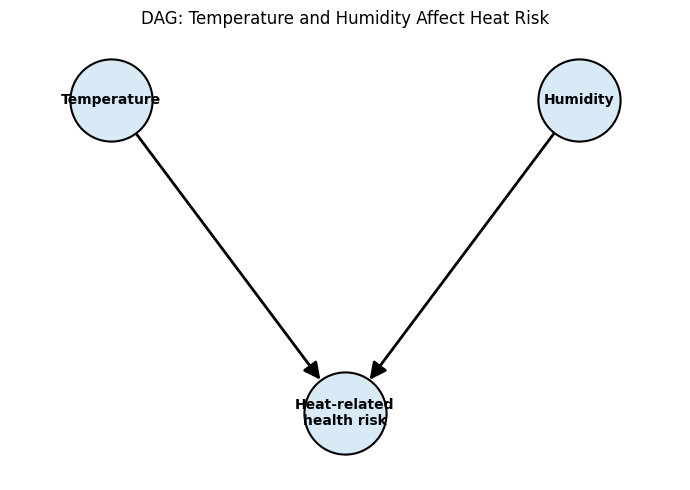


ADDITIVE MODEL
risk ~ temperature + humidity
                            OLS Regression Results                            
Dep. Variable:                   risk   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     1541.
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          1.25e-274
Time:                        13:59:27   Log-Likelihood:                -2572.4
No. Observations:                 800   AIC:                             5151.
Df Residuals:                     797   BIC:                             5165.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

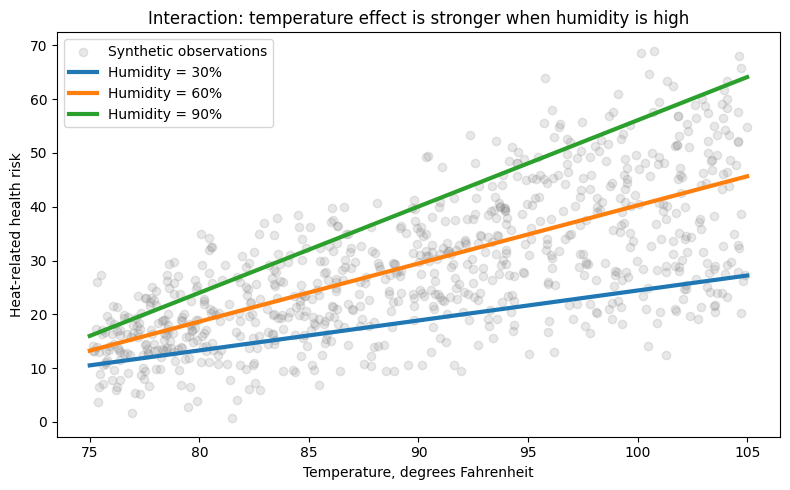

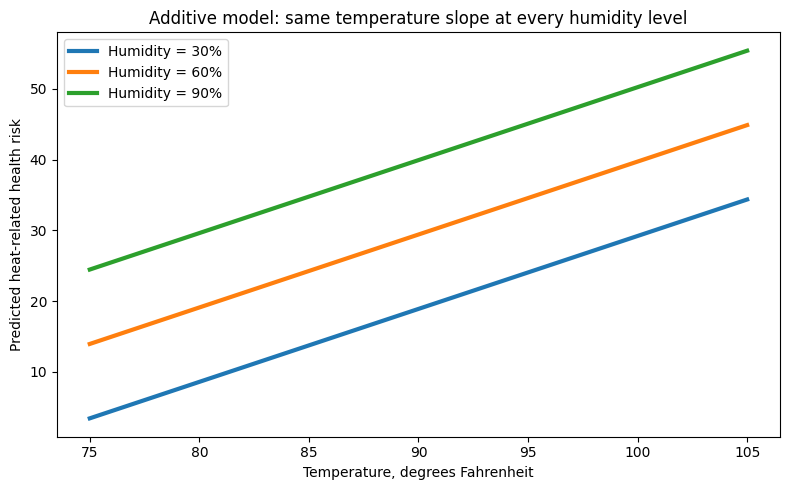

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm

np.random.seed(42)

n = 800

temperature = np.random.uniform(75, 105, size=n)
humidity = np.random.uniform(20, 95, size=n)

temp_c = temperature - 75
hum_c = humidity - 20

noise = np.random.normal(0, 5, size=n)

risk = (
    10
    + 0.35 * temp_c
    + 0.08 * hum_c
    + 0.018 * temp_c * hum_c
    + noise
)

df = pd.DataFrame({
    "temperature": temperature,
    "humidity": humidity,
    "temp_c": temp_c,
    "hum_c": hum_c,
    "temp_x_hum": temp_c * hum_c,
    "risk": risk
})

G = nx.DiGraph()

G.add_nodes_from([
    "Temperature",
    "Humidity",
    "Heat-related\nhealth risk"
])

G.add_edges_from([
    ("Temperature", "Heat-related\nhealth risk"),
    ("Humidity", "Heat-related\nhealth risk")
])

pos = {
    "Temperature": (-1, 1),
    "Humidity": (1, 1),
    "Heat-related\nhealth risk": (0, 0)
}

plt.figure(figsize=(7, 5))

ax = plt.gca()
ax.margins(0.15)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500,
    node_color="#D9EAF7",
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    width=2,
    node_size = 3500,
    min_source_margin=15,
    min_target_margin=20
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title("DAG: Temperature and Humidity Affect Heat Risk")
plt.axis("off")
plt.tight_layout()
plt.show()

X_additive = sm.add_constant(
    df[["temp_c", "hum_c"]],
    has_constant="add"
)

model_additive = sm.OLS(df["risk"], X_additive).fit()

X_interaction = sm.add_constant(
    df[["temp_c", "hum_c", "temp_x_hum"]],
    has_constant="add"
)

model_interaction = sm.OLS(df["risk"], X_interaction).fit()

print("\nADDITIVE MODEL")
print("risk ~ temperature + humidity")
print(model_additive.summary())

print("\nINTERACTION MODEL")
print("risk ~ temperature + humidity + temperature:humidity")
print(model_interaction.summary())

comparison = pd.DataFrame({
    "model": ["additive", "interaction"],
    "r_squared": [model_additive.rsquared, model_interaction.rsquared],
    "adj_r_squared": [model_additive.rsquared_adj, model_interaction.rsquared_adj],
    "residual_standard_error": [
        np.sqrt(model_additive.mse_resid),
        np.sqrt(model_interaction.mse_resid)
    ],
    "aic": [model_additive.aic, model_interaction.aic],
    "bic": [model_additive.bic, model_interaction.bic]
})

print("\nMODEL COMPARISON")
print(comparison)

temp_grid = np.linspace(75, 105, 200)
humidity_levels = [30, 60, 90]

plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature"],
    df["risk"],
    alpha=0.18,
    color="gray",
    label="Synthetic observations"
)

for h in humidity_levels:
    grid = pd.DataFrame({
        "temperature": temp_grid,
        "humidity": h
    })

    grid["temp_c"] = grid["temperature"] - 75
    grid["hum_c"] = grid["humidity"] - 20
    grid["temp_x_hum"] = grid["temp_c"] * grid["hum_c"]

    X_grid = sm.add_constant(
        grid[["temp_c", "hum_c", "temp_x_hum"]],
        has_constant="add"
    )

    grid["predicted_risk"] = model_interaction.predict(X_grid)

    plt.plot(
        grid["temperature"],
        grid["predicted_risk"],
        linewidth=3,
        label=f"Humidity = {h}%"
    )

plt.xlabel("Temperature, degrees Fahrenheit")
plt.ylabel("Heat-related health risk")
plt.title("Interaction: temperature effect is stronger when humidity is high")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

for h in humidity_levels:
    grid = pd.DataFrame({
        "temperature": temp_grid,
        "humidity": h
    })

    grid["temp_c"] = grid["temperature"] - 75
    grid["hum_c"] = grid["humidity"] - 20

    X_grid_additive = sm.add_constant(
        grid[["temp_c", "hum_c"]],
        has_constant="add"
    )

    grid["predicted_risk_additive"] = model_additive.predict(X_grid_additive)

    plt.plot(
        grid["temperature"],
        grid["predicted_risk_additive"],
        linewidth=3,
        label=f"Humidity = {h}%"
    )

plt.xlabel("Temperature, degrees Fahrenheit")
plt.ylabel("Predicted heat-related health risk")
plt.title("Additive model: same temperature slope at every humidity level")
plt.legend()
plt.tight_layout()
plt.show()

# Draw the DAG

## Combine the following variables into a DAG:

## Maternal Smoking

## Fetal Health Problems Unrelated to Smoking

## Low Birth Weight

## Infant Mortality

# **Prediction:** If low birth weight is strongly associated with infant mortality, should we control for it when estimating the effect of smoking?

## A. Yes, because it predicts mortality.  
## B. No, because it may be a collider or mediator.

# Colliders

## In some data in which only low-birth-weight babies are included, smoking can appear to have a protective effect.  Could that be true?

## A lot of us learn a simple rule early on: if a variable is related to the outcome, control for it. That rule is too simple. DAGs help us see why.

## Maternal smoking can contribute to low birth weight. But low birth weight can also be caused by other serious fetal-health problems.

## So low birth weight is a common effect of two different causes:

## Smoking → Low birth weight ← Fetal-health problems

## That middle variable, low birth weight, is called a **collider**, because two arrows collide into it.

## Don't control for colliders!

## Suppose we already know a baby has low birth weight. If the mother smoked, then smoking is one possible explanation for the low birth weight. But if the mother did not smoke, then we start looking for another explanation. One possible explanation is another health problem.  This makes the other health problem more likely than if the mother smoked.

## A collider is a variable that is caused by two other variables, and conditioning on it can create a statistical association that is not a causal effect.


BASIC RATES
smoking                 0.24818
severe_fetal_problem    0.07764
low_birth_weight        0.10456
infant_mortality        0.01838
dtype: float64

MORTALITY RATE BY SMOKING STATUS, FULL POPULATION
smoking
0    0.017398
1    0.021355
Name: infant_mortality, dtype: float64

MORTALITY RATE BY SMOKING STATUS, ONLY LOW-BIRTH-WEIGHT BABIES
smoking
0    0.068118
1    0.060084
Name: infant_mortality, dtype: float64

UNADJUSTED MODEL: infant_mortality ~ smoking
               coef  odds_ratio    ci_low   ci_high   p_value
Intercept -4.033862    0.017706  0.016388  0.019129  0.000000
smoking    0.209001    1.232446  1.066959  1.423600  0.004498

BAD CONTROL MODEL: infant_mortality ~ smoking + low_birth_weight
                      coef  odds_ratio    ci_low   ci_high        p_value
Intercept        -4.306665    0.013478  0.012350  0.014710   0.000000e+00
smoking          -0.107492    0.898084  0.773219  1.043112   1.593253e-01
low_birth_weight  1.679286    5.361725  4.654365  6.176587 

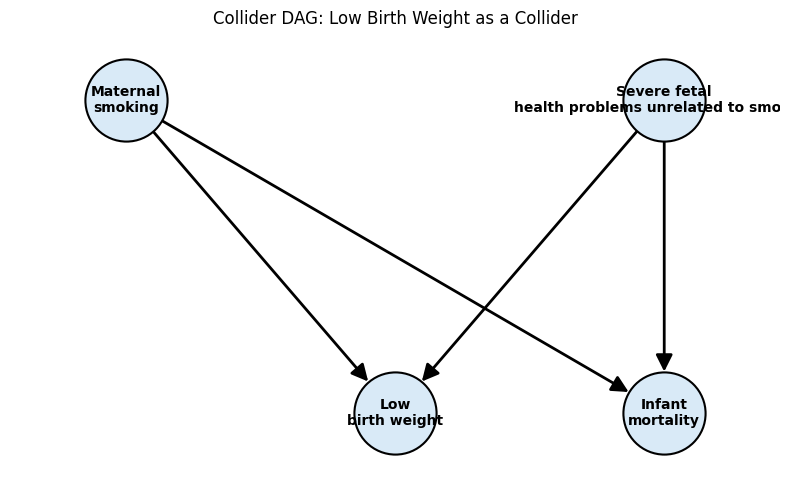

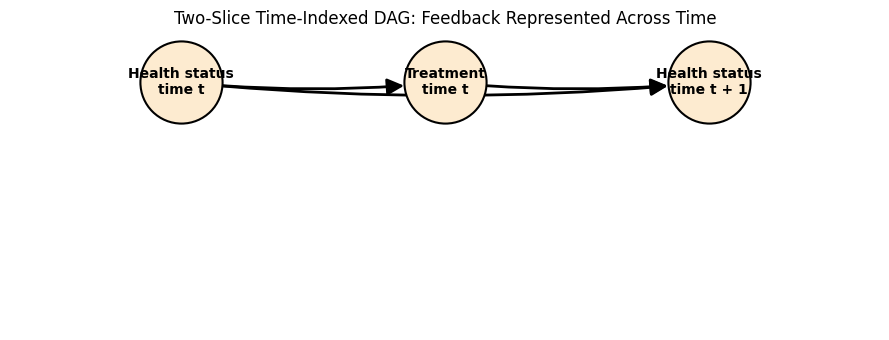

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.formula.api as smf

np.random.seed(42)

n = 50000

def logistic(x):
    return 1 / (1 + np.exp(-x))

smoking = np.random.binomial(1, 0.25, size=n)

severe_fetal_problem = np.random.binomial(1, 0.08, size=n)

p_low_birth_weight = logistic(
    -3.2
    + 1.4 * smoking
    + 3.2 * severe_fetal_problem
)

low_birth_weight = np.random.binomial(1, p_low_birth_weight)

p_infant_mortality = logistic(
    -5.0
    + 0.20 * smoking
    + 3.2 * severe_fetal_problem
)

infant_mortality = np.random.binomial(1, p_infant_mortality)

df = pd.DataFrame({
    "smoking": smoking,
    "severe_fetal_problem": severe_fetal_problem,
    "low_birth_weight": low_birth_weight,
    "infant_mortality": infant_mortality
})

print("\nBASIC RATES")
print(df.mean())

print("\nMORTALITY RATE BY SMOKING STATUS, FULL POPULATION")
print(df.groupby("smoking")["infant_mortality"].mean())

print("\nMORTALITY RATE BY SMOKING STATUS, ONLY LOW-BIRTH-WEIGHT BABIES")
print(
    df[df["low_birth_weight"] == 1]
    .groupby("smoking")["infant_mortality"]
    .mean()
)

def summarize_logit(model, label):
    params = model.params
    conf = model.conf_int()
    out = pd.DataFrame({
        "coef": params,
        "odds_ratio": np.exp(params),
        "ci_low": np.exp(conf[0]),
        "ci_high": np.exp(conf[1]),
        "p_value": model.pvalues
    })
    print(f"\n{label}")
    print(out)

model_unadjusted = smf.logit(
    "infant_mortality ~ smoking",
    data=df
).fit(disp=False)

model_adjust_low_bw = smf.logit(
    "infant_mortality ~ smoking + low_birth_weight",
    data=df
).fit(disp=False)

model_selected_low_bw = smf.logit(
    "infant_mortality ~ smoking",
    data=df[df["low_birth_weight"] == 1]
).fit(disp=False)

model_oracle = smf.logit(
    "infant_mortality ~ smoking + severe_fetal_problem",
    data=df
).fit(disp=False)

summarize_logit(
    model_unadjusted,
    "UNADJUSTED MODEL: infant_mortality ~ smoking"
)

summarize_logit(
    model_adjust_low_bw,
    "BAD CONTROL MODEL: infant_mortality ~ smoking + low_birth_weight"
)

summarize_logit(
    model_selected_low_bw,
    "SELECTED SAMPLE MODEL: infant_mortality ~ smoking, among low-birth-weight babies only"
)

summarize_logit(
    model_oracle,
    "ORACLE MODEL: infant_mortality ~ smoking + severe_fetal_problem"
)

print("\nPLACEBO / NEGATIVE-CONTROL STYLE CHECK")
print("In the synthetic data, smoking does not cause severe_fetal_problem.")
print("So smoking and severe_fetal_problem should be unrelated in the full population.")
print("But after conditioning on low_birth_weight, they become associated.")

model_placebo_unadjusted = smf.logit(
    "severe_fetal_problem ~ smoking",
    data=df
).fit(disp=False)

model_placebo_conditioned = smf.logit(
    "severe_fetal_problem ~ smoking + low_birth_weight",
    data=df
).fit(disp=False)

model_placebo_selected = smf.logit(
    "severe_fetal_problem ~ smoking",
    data=df[df["low_birth_weight"] == 1]
).fit(disp=False)

summarize_logit(
    model_placebo_unadjusted,
    "PLACEBO TEST, FULL POPULATION: severe_fetal_problem ~ smoking"
)

summarize_logit(
    model_placebo_conditioned,
    "PLACEBO TEST, CONDITIONING ON COLLIDER: severe_fetal_problem ~ smoking + low_birth_weight"
)

summarize_logit(
    model_placebo_selected,
    "PLACEBO TEST, LOW-BIRTH-WEIGHT SAMPLE ONLY: severe_fetal_problem ~ smoking"
)

G = nx.DiGraph()

G.add_edges_from([
    ("Maternal\nsmoking", "Low\nbirth weight"),
    ("Severe fetal\nhealth problems unrelated to smoking", "Low\nbirth weight"),
    ("Severe fetal\nhealth problems unrelated to smoking", "Infant\nmortality"),
    ("Maternal\nsmoking", "Infant\nmortality")
])

pos = {
    "Maternal\nsmoking": (-2, 1),
    "Severe fetal\nhealth problems unrelated to smoking": (2, 1),
    "Low\nbirth weight": (0, -1),
    "Infant\nmortality": (2, -1)
}

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.margins(0.15)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500,
    node_color="#D9EAF7",
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    width=2,
    node_size = 3500,
    min_source_margin=15,
    min_target_margin=20
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Collider DAG: Low Birth Weight as a Collider")
plt.axis("off")
plt.tight_layout()
plt.show()

G_time = nx.DiGraph()

G_time.add_edges_from([
    ("Health status\ntime t", "Treatment\ntime t"),
    ("Health status\ntime t", "Health status\ntime t + 1"),
    ("Treatment\ntime t", "Health status\ntime t + 1")
])

pos_time = {
    "Health status\ntime t": (0, 1),
    "Treatment\ntime t": (2.5, 1),
    "Health status\ntime t + 1": (5, 1)
}

plt.figure(figsize=(9, 3.5))
ax = plt.gca()
ax.margins(0.25)

nx.draw_networkx_nodes(
    G_time,
    pos_time,
    node_size=3500,
    node_color="#FDEBD0",
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_edges(
    G_time,
    pos_time,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    width=2,
    node_size = 3500,
    min_source_margin=15,
    min_target_margin=20,
    connectionstyle="arc3,rad=0.05"
)

nx.draw_networkx_labels(
    G_time,
    pos_time,
    font_size=10,
    font_weight="bold"
)

plt.title("Two-Slice Time-Indexed DAG: Feedback Represented Across Time")
plt.axis("off")
plt.tight_layout()
plt.show()

## In the above: The path from Maternal smoking -> Low birth rate <- Unrelated health problems -> Infant mortality
## Is NOT a confounding path.  Why?  It contains a confounder (two outgoing arrows)
## But it also contains a collider (two incoming arrows)
## We should not control for low birth rate, but if we do, we could fix it
## by controlling for Unrelated health problems.

In [ ]:
health_status_t = [1, 3, 2, 4, 5]
health_status_t_1 = [3, 2, 4, 5, ?]

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 health   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.581
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.108
Time:                        19:45:22   Log-Likelihood:                -1420.5
No. Observations:                1000   AIC:                             2845.
Df Residuals:                     998   BIC:                             2855.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0234      0.032      0.738      0.461      -0.039       0.086
smoking       -0.0485      0.030     -1.606      0.108      -0.108       0.011
==============================================================================
Omnibus:                        3.028   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.220   Jarque-Bera (JB):                3.302
Skew:                           0.025   Prob(JB):                        0.192
Kurtosis:                       3.277   Cond. No.                         1.05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

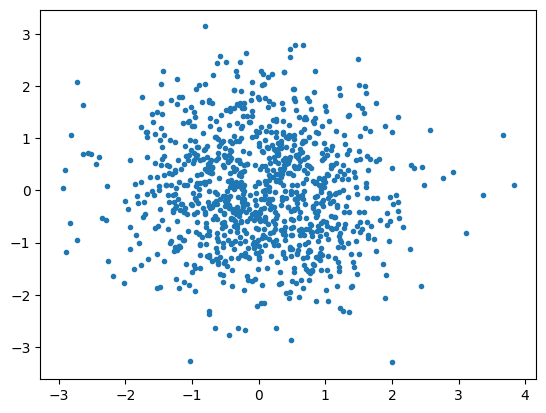

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

health = np.random.normal(0, 1, 1000)
smoking = np.random.normal(0, 1, 1000)
weight = 5 - health - smoking + np.random.normal(0, 1, 1000)

df = pd.DataFrame({"health": health, "smoking": smoking, "weight": weight})

dfq = df #df.query("weight > 5")

plt.plot(dfq.health, dfq.smoking, ".")

result = sm.OLS(dfq.health, sm.add_constant(dfq[["smoking"]])).fit()
result.summary()